In [ ]:
# Core data and viz (D,S, P, F, M, E)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Splitting libraries
from sklearn.model_selection import train_test_split, cross_val_score

# Preprocessing libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Feature selection libraries
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

# Modeling libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster

# Evaluation libraries
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,silhouette_score

In [ ]:
df = pd.read_csv('customer_segmentation_data.csv')
print(df.head())

   minutes_watched     CLV  region  channel
0           3197.0  205.42       2        4
1             63.0  149.99       0        1
2            605.0  119.00       2        2
3             20.0  240.00       2        4
4            245.0  184.36       1        4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3834 entries, 0 to 3833
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  3725 non-null   float64
 1   CLV              3834 non-null   float64
 2   region           3834 non-null   int64  
 3   channel          3834 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 119.9 KB


In [ ]:
df.describe()

,minutes_watched,CLV,region,channel
count,3725.000000,3834.000000,3834.000000,3834.000000
mean,1972.094497,118.383920,1.167188,3.870370
std,7401.693028,70.471274,0.923055,2.191972
min,0.000000,0.000000,0.000000,1.000000
25%,159.000000,62.580000,0.000000,2.000000
50%,512.000000,119.000000,2.000000,3.000000
75%,1521.000000,149.990000,2.000000,6.000000
max,288508.000000,626.400000,2.000000,8.000000


## Data Cleaning and Preprocessing

In [ ]:
df.isnull().sum()

,0
minutes_watched,109
CLV,0
region,0
channel,0


In [ ]:
df['minutes_watched'] = df['minutes_watched'].fillna(0)

In [ ]:
df.isnull().sum()

,0
minutes_watched,0
CLV,0
region,0
channel,0


In [ ]:
df_engineered = df.copy()
df.copy()

,minutes_watched,CLV,region,channel
0,3197.0,205.42,2,4
1,63.0,149.99,0,1
2,605.0,119.00,2,2
3,20.0,240.00,2,4
4,245.0,184.36,1,4
...,...,...,...,...
3829,11.0,79.00,0,3
3830,28.0,79.00,0,2
3831,57.0,36.00,2,2
3832,44.0,36.00,2,1


In [ ]:
df_engineered = df.copy()

# Region mapping
region_map = {
    0: "Anglo-Saxon",
    1: "Western Europe",
    2: "Rest of World"
}

# Channel mapping
channel_map = {
    1: "Google",
    2: "Facebook",
    3: "YouTube",
    4: "LinkedIn",
    5: "Twitter",
    6: "Instagram",
    7: "Friend",
    8: "Other"
}

df_engineered["Region"] = df_engineered["region"].map(region_map)
df_engineered["Channel"] = df_engineered["channel"].map(channel_map)

df_engineered.drop(columns=['region', 'channel'], inplace=True)

df_engineered.head()

,minutes_watched,CLV,Region,Channel
0,3197.0,205.42,Rest of World,LinkedIn
1,63.0,149.99,Anglo-Saxon,Google
2,605.0,119.00,Rest of World,Facebook
3,20.0,240.00,Rest of World,LinkedIn
4,245.0,184.36,Western Europe,LinkedIn


# **Exploratory Data Analysis (EDA)**

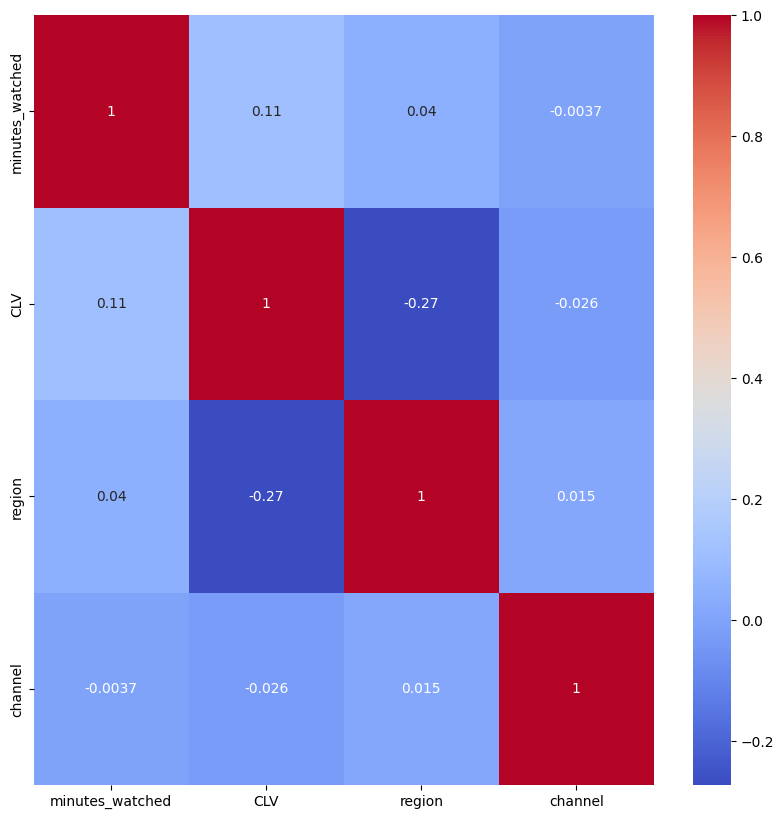

In [ ]:
#correlation heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

/tmp/ipython-input-1685990994.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


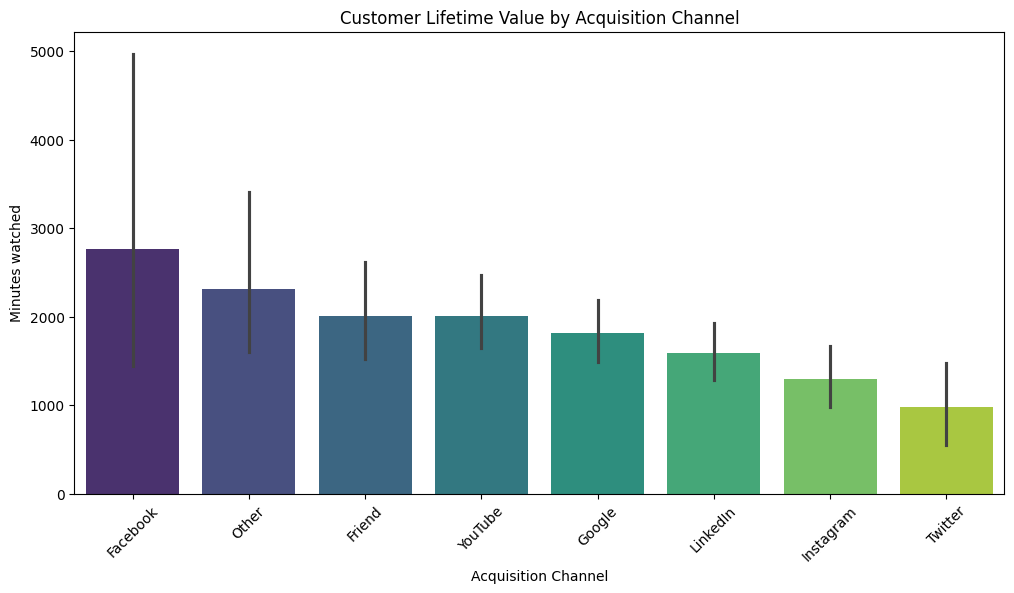

In [ ]:
# Visualization: Minutes Watched by Channel

channel_order = df_engineered.groupby('Channel')['minutes_watched'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(
    x="Channel",
    y="minutes_watched",
    data=df_engineered,
    order=channel_order,
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("Customer Lifetime Value by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Minutes watched")
plt.show()

/tmp/ipython-input-725195213.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


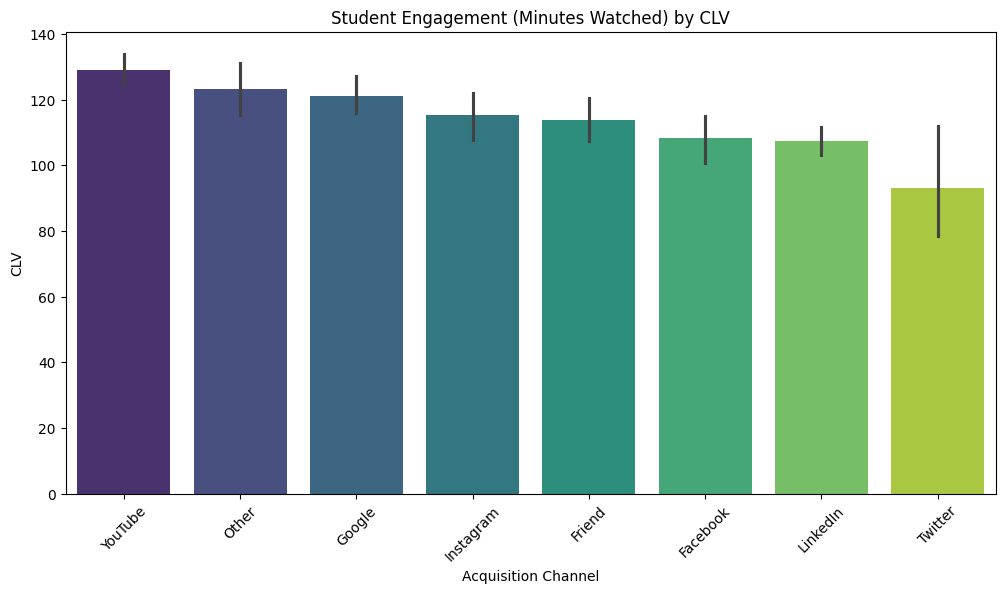

In [ ]:
# Which channels bring higher-value customers? Viz

clv_order = df_engineered.groupby('Channel')['CLV'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(
    x="Channel",
    y="CLV",
    data=df_engineered,
    order=clv_order,
    palette="viridis"
)
plt.xticks(rotation=45)
plt.title("Student Engagement (Minutes Watched) by CLV")
plt.xlabel("Acquisition Channel")
plt.ylabel("CLV")
plt.show()

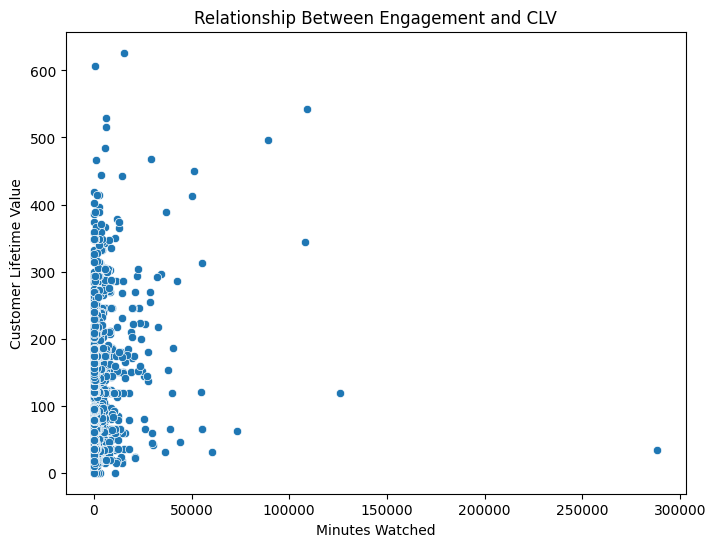

In [ ]:
# Does engagement relate to value?

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="minutes_watched",
    y="CLV",
    data=df_engineered,
)
plt.title("Relationship Between Engagement and CLV")
plt.xlabel("Minutes Watched")
plt.ylabel("Customer Lifetime Value")
plt.show()


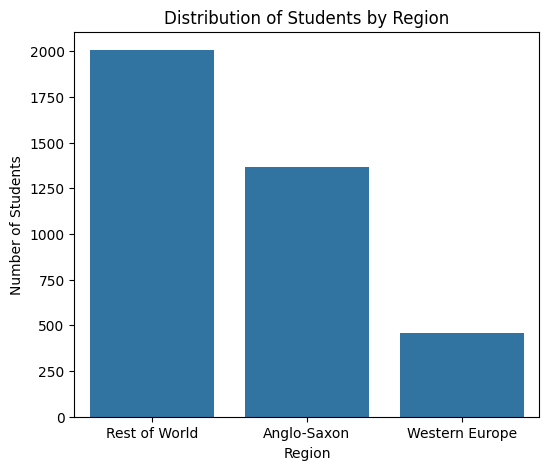

In [ ]:
# Where do students come from Geographically

plt.figure(figsize=(6, 5))
sns.countplot(
    x="Region",
    data=df_engineered
)
plt.title("Distribution of Students by Region")
plt.xlabel("Region")
plt.ylabel("Number of Students")
plt.show()


Text(0.5, 1.0, 'Channel Dominance by Region')

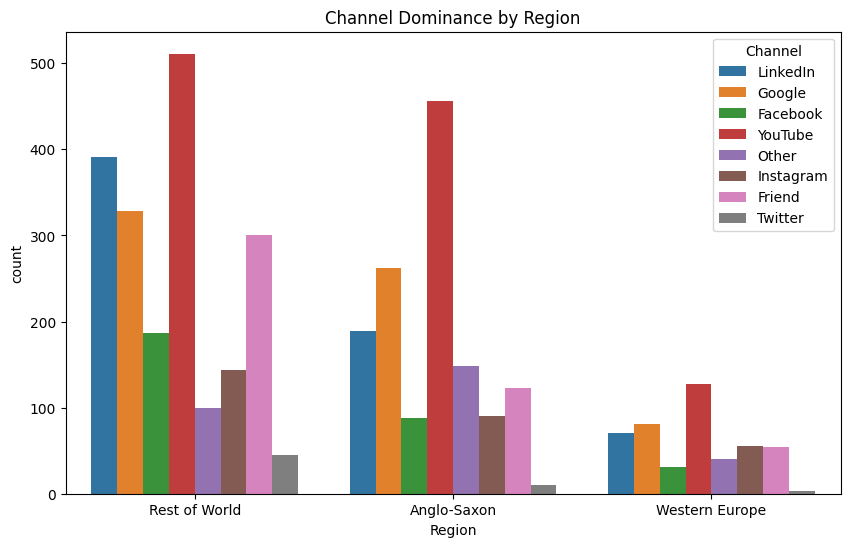

In [ ]:
# Which channels dominate each region?

plt.figure(figsize=(10, 6))
sns.countplot(
    x="Region",
    hue="Channel",
    data=df_engineered
)
plt.title("Channel Dominance by Region")

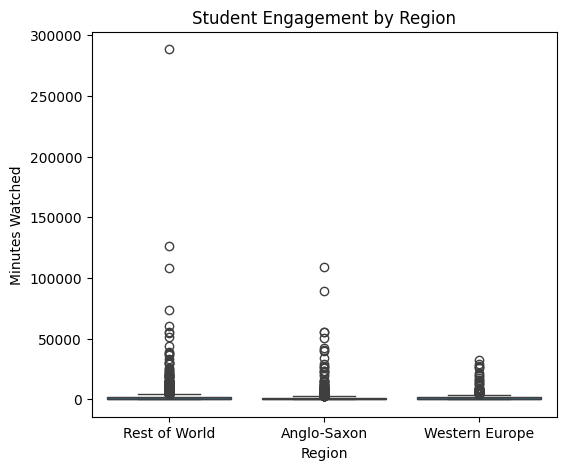

In [ ]:
# Which regions bring higher engagement?

plt.figure(figsize=(6, 5))
sns.boxplot(
    x="Region",
    y="minutes_watched",
    data=df_engineered
)
plt.title("Student Engagement by Region")
plt.xlabel("Region")
plt.ylabel("Minutes Watched")
plt.show()


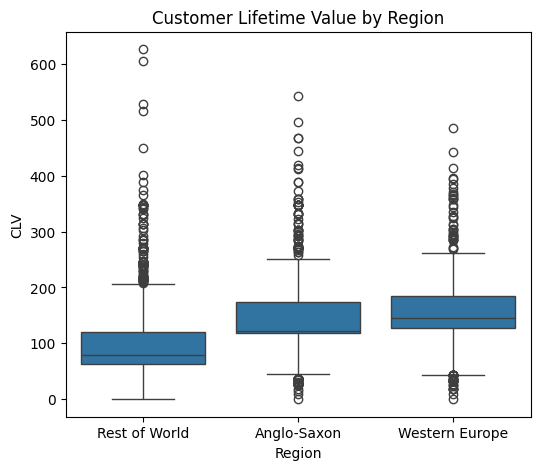

In [ ]:
# Which regions generate more value?

plt.figure(figsize=(6, 5))
sns.boxplot(
    x="Region",
    y="CLV",
    data=df_engineered
)
plt.title("Customer Lifetime Value by Region")
plt.xlabel("Region")
plt.ylabel("CLV")
plt.show()


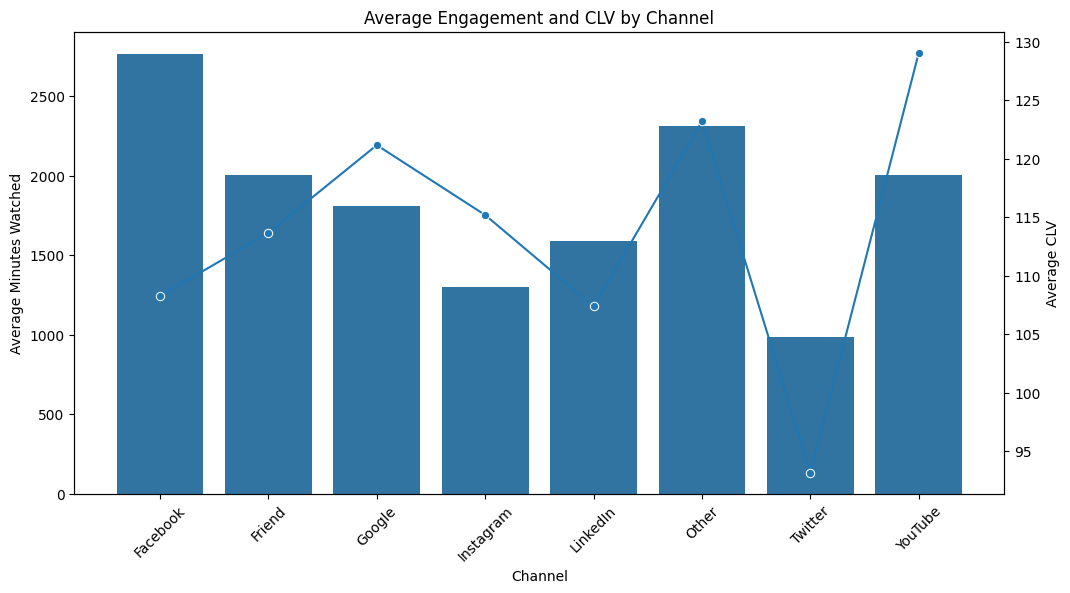

In [ ]:
# Combined Insight: Average Engagement & CLV by Channel

channel_summary = df_engineered.groupby("Channel").agg(
    avg_minutes=("minutes_watched", "mean"),
    avg_clv=("CLV", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    x="Channel",
    y="avg_minutes",
    data=channel_summary,
    ax=ax1
)
ax1.set_ylabel("Average Minutes Watched")
ax1.set_xlabel("Channel")
ax1.set_title("Average Engagement and CLV by Channel")
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(
    x="Channel",
    y="avg_clv",
    data=channel_summary,
    ax=ax2,
    marker="o"
)
ax2.set_ylabel("Average CLV")

plt.show()


# **Interpretetion**
---

***Ideal Channels (High Engagement & High CLV):***

1. YouTube stands out with the highest average CLV dollars (129.05) and very strong engagement (over 2000 minutes watched). This indicates it's effective at acquiring and retaining valuable customers.
2. The 'Other' channel also performs well, with the second-highest average CLV dollars (123.19) and high engagement (over 2300 minutes watched). This suggests a diverse set of high-performing sources not categorized elsewhere.
3. Google shows a good balance, with high average CLV dollars (121.15) and solid engagement.

***Channels High on Engagement but Lower on CLV (Potential for Optimization):***

1. Facebook has the highest average minutes watched (around 2768 minutes), indicating high engagement. However, its average CLV dollars (108.26) is relatively lower compared to the top performers. Such channels may need pricing or funnel optimization to convert engaged users into higher-value customers.

In [ ]:
df_engineered.head()

,minutes_watched,CLV,Region,Channel
0,3197.0,205.42,Rest of World,LinkedIn
1,63.0,149.99,Anglo-Saxon,Google
2,605.0,119.00,Rest of World,Facebook
3,20.0,240.00,Rest of World,LinkedIn
4,245.0,184.36,Western Europe,LinkedIn


In [ ]:
df.head()

,minutes_watched,CLV,region,channel
0,3197.0,205.42,2,4
1,63.0,149.99,0,1
2,605.0,119.00,2,2
3,20.0,240.00,2,4
4,245.0,184.36,1,4


## **Feature Engineering**

In [ ]:
# # One-Hot-Encoding

# df_encoded = pd.get_dummies(df_engineered, columns=['Region', 'Channel'])
# df_encoded.head()

# **Feature Splitting**

In [ ]:
features = ['minutes_watched', 'CLV', 'region', 'channel']
X = df[features].drop('channel', axis=1)
y= df['channel']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Feature Scaling**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **KNN Modelling**

In [ ]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

In [ ]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.20      0.31      0.24       143
           2       0.24      0.11      0.15        75
           3       0.31      0.42      0.36       213
           4       0.24      0.24      0.24       131
           5       0.00      0.00      0.00        15
           6       0.04      0.02      0.03        53
           7       0.21      0.10      0.14        88
           8       0.07      0.04      0.05        49

    accuracy                           0.24       767
   macro avg       0.16      0.15      0.15       767
weighted avg       0.22      0.24      0.22       767



<!-- Cross Validation -->

## **Cross Validation**

In [ ]:
k_values = range(2, 21)
cv_scores = []

In [ ]:
for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(knn,X_train_scaled,y_train,cv=5,scoring='accuracy')
  cv_scores.append(scores.mean())

In [ ]:
optimal_k = k_values[cv_scores.index(max(cv_scores))]
print(f"Optimal k value: {optimal_k}")

Optimal k value: 11


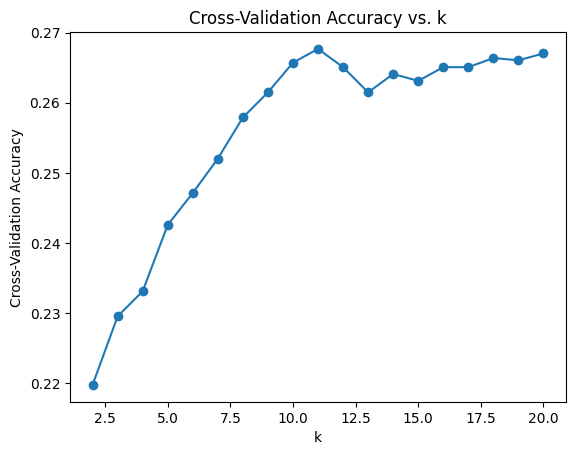

In [ ]:
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Cross-Validation Accuracy vs. k')
plt.show()

## **Final KNN Model**

In [ ]:
nn_model = KNeighborsClassifier(n_neighbors=optimal_k)
nn_model.fit(X_train_scaled, y_train)
y_pred = nn_model.predict(X_test_scaled)

In [ ]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.21      0.27      0.24       143
           2       0.12      0.04      0.06        75
           3       0.31      0.50      0.38       213
           4       0.23      0.24      0.24       131
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00        53
           7       0.22      0.12      0.16        88
           8       0.17      0.04      0.07        49

    accuracy                           0.25       767
   macro avg       0.16      0.15      0.14       767
weighted avg       0.21      0.25      0.22       767



## **KMeans Clustering**

In [ ]:
df_engineered.head()

,minutes_watched,CLV,Region,Channel
0,3197.0,205.42,Rest of World,LinkedIn
1,63.0,149.99,Anglo-Saxon,Google
2,605.0,119.00,Rest of World,Facebook
3,20.0,240.00,Rest of World,LinkedIn
4,245.0,184.36,Western Europe,LinkedIn


In [ ]:
features = df[['minutes_watched', 'CLV','region', 'channel']]
features.head()
X=features


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
k_values = range(2, 21)
inertia_values = []
silhouette_scores = []

for k in k_values:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

  print(f"K={k}: Inertia={inertia_values[-1]}, Silhouette Score={silhouette_scores[-1]}")

K=2: Inertia=12344.985046854976, Silhouette Score=0.28363853307111186
K=3: Inertia=10403.112551432136, Silhouette Score=0.28750792068896663
K=4: Inertia=7484.018128931913, Silhouette Score=0.3614941133500135
K=5: Inertia=6262.168174867598, Silhouette Score=0.38044973115517017
K=6: Inertia=5287.64744200395, Silhouette Score=0.3951885918310979
K=7: Inertia=4456.807293168377, Silhouette Score=0.40064331548173426
K=8: Inertia=4523.428115177427, Silhouette Score=0.36098189461435354
K=9: Inertia=3774.42170592643, Silhouette Score=0.3799667894875447
K=10: Inertia=3525.1334075921836, Silhouette Score=0.3494880526418707
K=11: Inertia=3015.7374784178974, Silhouette Score=0.349831505490506
K=12: Inertia=2887.7267867904156, Silhouette Score=0.3360219745275735
K=13: Inertia=2731.1100639260753, Silhouette Score=0.3313427167778454
K=14: Inertia=2623.6710884089075, Silhouette Score=0.31274118134129486
K=15: Inertia=2424.626845843744, Silhouette Score=0.31480763469450374
K=16: Inertia=2218.916036346437

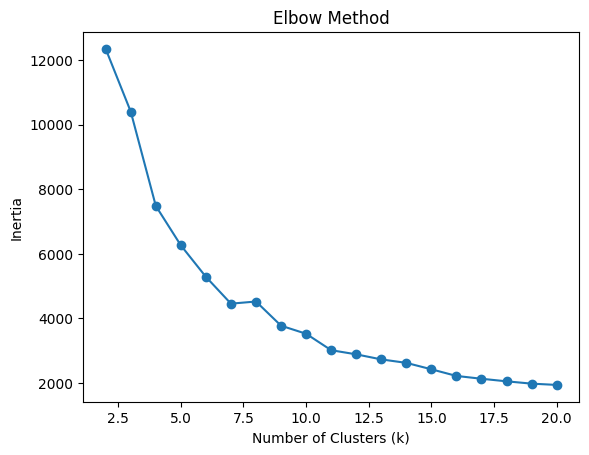

In [ ]:
# Inertia Values againts value of k

plt.plot(k_values, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Text(0, 0.5, 'Silhouette Score')

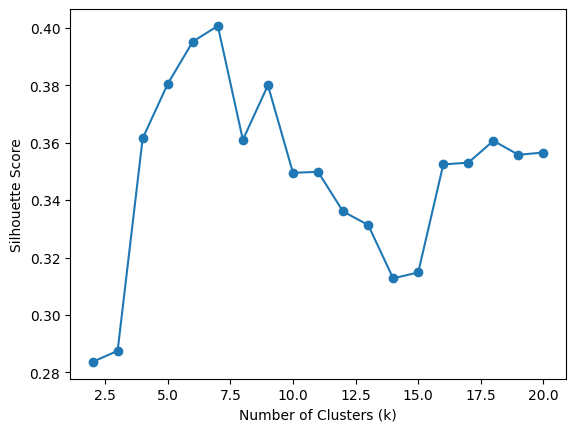

In [ ]:
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

In [ ]:
optimal_kmeans = KMeans(n_clusters = 7, random_state=42)
optimal_kmeans.fit(X_scaled)
optimal_kmeans.labels_

array([4, 3, 0, ..., 0, 0, 3], dtype=int32)

In [ ]:
labels = optimal_kmeans.labels_
labels

array([4, 3, 0, ..., 0, 0, 3], dtype=int32)

In [ ]:
# DataFrame xgb that contains the mean values of the features in X for each of the clusters in the final_model

xgb = X.groupby(optimal_kmeans.labels_).mean()

print("xgb type:", type(xgb))
print("xgb shape:", xgb.shape)
xgb

xgb type: <class 'pandas.core.frame.DataFrame'>
xgb shape: (5, 4)


,minutes_watched,CLV,region,channel
0,1600.724017,85.285513,1.965590,2.735253
1,1512.787751,104.995787,1.275607,7.052798
2,132411.166667,266.546667,1.333333,4.500000
3,1025.231615,130.597523,0.153846,2.802198
4,5936.843066,280.694234,1.014599,3.368613


In [ ]:
# PCA transformer to reduce the dimensionality of the data in X to 2

# Instantiate transformer
pca = PCA(n_components=2, random_state=42)

# Transform `X`
X_t = pca.fit_transform(X)

# Put `X_t` into DataFrame
X_pca = pd.DataFrame(X_t, columns =["PC1", "PC2"])

print("X_pca type:", type(X_pca))
print("X_pca shape:", X_pca.shape)
X_pca.head()

X_pca type: <class 'pandas.core.frame.DataFrame'>
X_pca shape: (3834, 2)


,PC1,PC2
0,1281.066939,85.621109
1,-1852.992229,33.653784
2,-1311.026688,2.058762
3,-1895.893039,123.700625
4,-1670.954475,67.816884


In [ ]:
# scatter plot of `PC2` vs `PC1`
import plotly.express as px

labels = optimal_kmeans.labels_
fig = px.scatter(
    data_frame = X_pca,
    x= "PC1",
    y = "PC2",
    color = labels.astype(str),
    title = "PCA Representation of Clusters"
)
fig.update_layout(xaxis_title = "PC1", yaxis_title = "PC2")
fig.show()